<a href="https://colab.research.google.com/github/pramodgurung10/AI-ML/blob/main/Tutorial7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Input space/(z) lai latent space ma rakhcha teslai core space pani vancha. Tesma chaine data haru stored huncha aani output nakalana sakcha. Yeslai self supervised learning pani vancha.

Genetic Ai ko foundation nai encoder decoder ho. Anamoly detection ma ni use huncha.



undercomplete architecture

z > input

z > input overcomplete architecture. Certain percent matra accurate huncha.

Vanila auto encoders


#Application of Autoencoder: Denoising.

Step 1: Load, pre - process and add a Noise to the Dataset:

1.1 Tasks to Do:
1. Load the MNIST dataset using keras.
2. Normalize the images to be in the range [0 - 1] {rescaling}.
3. Reshape the images to be 28 × 28 × 1.
4. Add a Gaussian noise to the images with noise factor of 0.5.
5. Clip the noisy images to ensure all pixel values are between 0 and 1.
6. Visualize the Input image and Noise added image.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


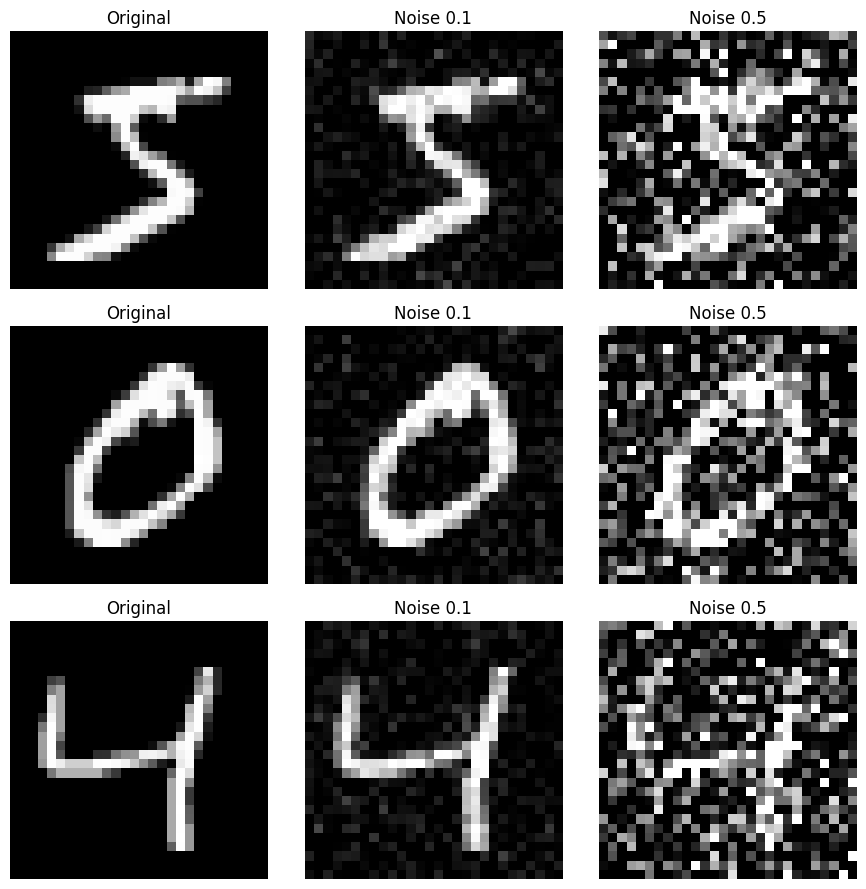

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.
shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train
.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.
shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')
    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')
plt.tight_layout()
plt.show()


Step 2: Build the Convolutional Denoising Autoencoder Model:

2.1 Tasks to Do:

  • Encoder:

  – Convolutional Layers + ReLU activation.

  – Maxpooling to down-sample the features.

• Decoder:

– Convolutional layers + ReLU activation.

– Upsampling to upsample the feature maps.

– Final Layer with sigmoid activation to keep output pixels in range [0, 1].

• Transpose Convolutional is achieved in Keras using convolutional and Upsampling
operations.

• Compile the Model with binary crossentropy loss and ADAM optimizer.

In [4]:
#encoder
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    Parameters:
    input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
    Returns:
    input_img (Keras Input): Input layer of the model.
    encoded (Keras Tensor): Encoded representation after convolution and pooling.
    """
    from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

In [5]:
#decoder
def build_decoder(encoded_input):
  """"
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
    encoded_input (Keras Tensor): The output from the encoder.
  Returns:
    decoded (Keras Tensor): The reconstructed output after upsampling and
    convolution.
  """
  from tensorflow.keras.layers import Conv2D, UpSampling2D
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  y = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(y)
  y = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoded')(y)
  return decoded

In [6]:
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import UpSampling2D

#complete auto encoder
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting encoder and
    decoder.
    Returns:
    autoencoder (Keras Model): Compiled autoencoder model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

In [7]:
#compling the model
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

Step 3: Train the Autoencoder:

3.1 Tasks to Do:

• Train the autoencoder using the noisy images as input and the clean images as the target.

• Monitor the training and validation loss during training.

In [8]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1665 - val_loss: 0.1141
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1101 - val_loss: 0.1064
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1051 - val_loss: 0.1029
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1027 - val_loss: 0.1011
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1012 - val_loss: 0.1003
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1000 - val_loss: 0.0990
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0990 - val_loss: 0.0984
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0983 - val_loss: 0.0980
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0977 - val_loss: 0.0969
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0972 - val_loss: 0.0966


Step 4: Evaluate the Autoencoder:

4.1 Tasks to Do:

    • Use the trained autoencoder to predict the denoised images from the noisy test images.

    • Display the original noisy images, the denoised images, and the clean images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


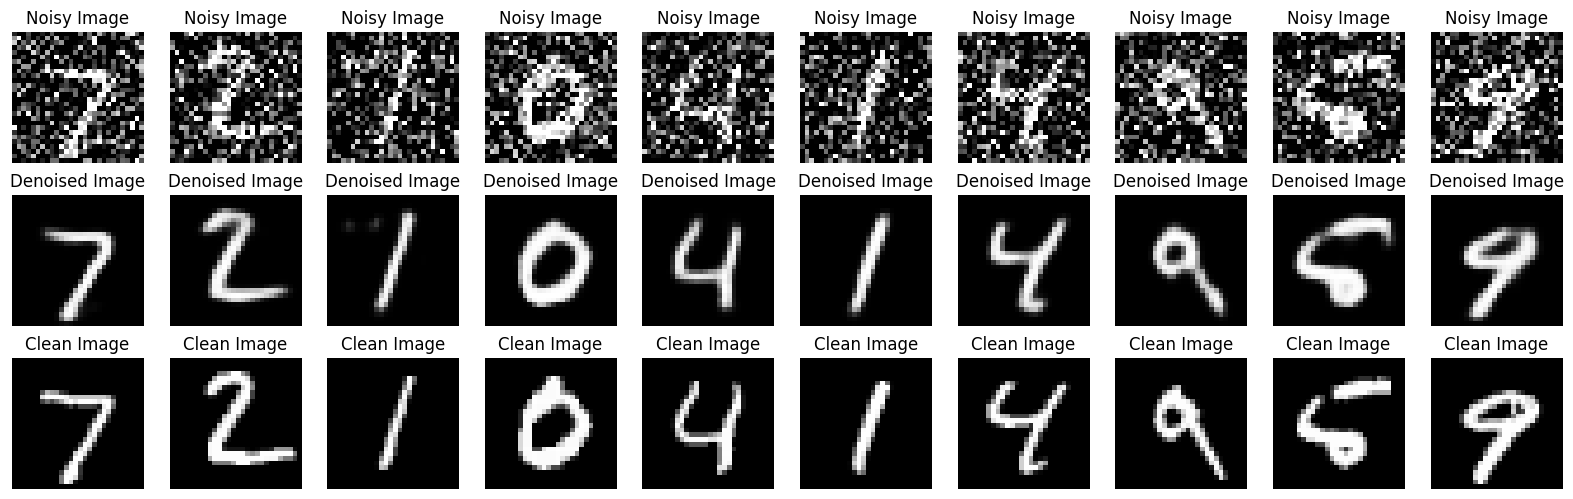

In [9]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')
        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')
        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

Build a Denoising Convolutional Autoencoder

In [12]:
base_path = "/content/drive/MyDrive/ConceptAI/DevanagariHandwrittenDigitDataset"

train_path = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"
test_path  = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test"

print("Train path:", train_path)
print("Test path:", test_path)

Train path: /content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train
Test path: /content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test


In [11]:
from PIL import Image
import numpy as np
import os

def load_images_from_folder(folder):
    images = []

    for digit_folder in os.listdir(folder):
        digit_path = os.path.join(folder, digit_folder)

        if not os.path.isdir(digit_path):
            continue

        for img_file in os.listdir(digit_path):
            img_path = os.path.join(digit_path, img_file)

            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((32, 32))
                img = np.array(img)
                images.append(img)
            except:
                continue

    return images

# Load both sets
train_images = load_images_from_folder(train_path)
test_images  = load_images_from_folder(test_path)

# Combine
images = np.array(train_images + test_images)

print("Total images loaded:", images.shape)

Total images loaded: (19999, 32, 32)


In [13]:
images = images.astype('float32') / 255.0
images = images.reshape(-1, 32, 32, 1)

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_val = train_test_split(images, test_size=0.2, random_state=42)

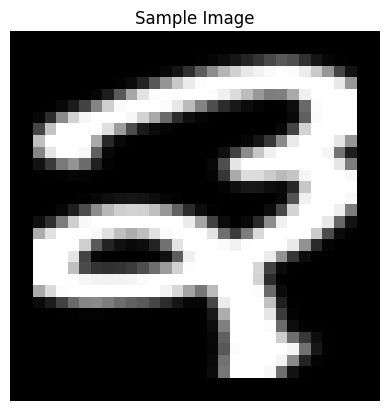

In [15]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0].reshape(32,32), cmap='gray')
plt.title("Sample Image")
plt.axis('off')
plt.show()

In [16]:
# Gaussian noise
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_val_noisy = x_val + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)

# Clip values to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

In [17]:
# Gaussian noise
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_val_noisy = x_val + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)

# Clip values to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

In [18]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(32, 32, 1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

# Bottleneck
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

# Decoder
x = UpSampling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,217 (723.50 KB)

 Trainable params: 185,217 (723.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - loss: 0.2487 - val_loss: 0.1714
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1641 - val_loss: 0.1580
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1565 - val_loss: 0.1536
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1528 - val_loss: 0.1522
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1497 - val_loss: 0.1479
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1479 - val_loss: 0.1475
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1464 - val_loss: 0.1454
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1453 - val_loss: 0.1446
Epoch 9/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1442 - val_loss: 0.1437
Epoch 10/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1432 - val_loss: 0.1430
Epoch 11/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1427 - val_loss: 0.1421
Epoch 12/20
125/125 ━━━━━━━━━━━━━━━━━━━━

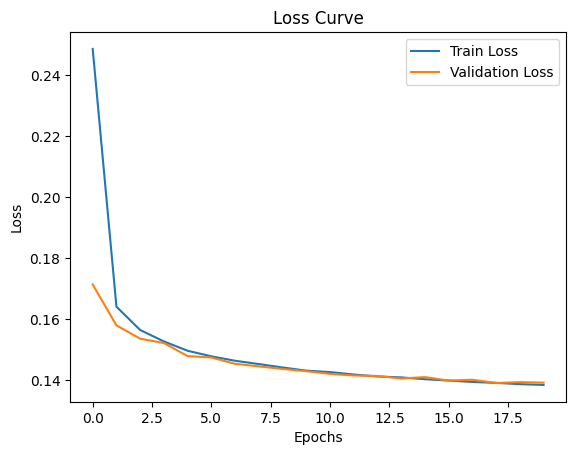

In [20]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


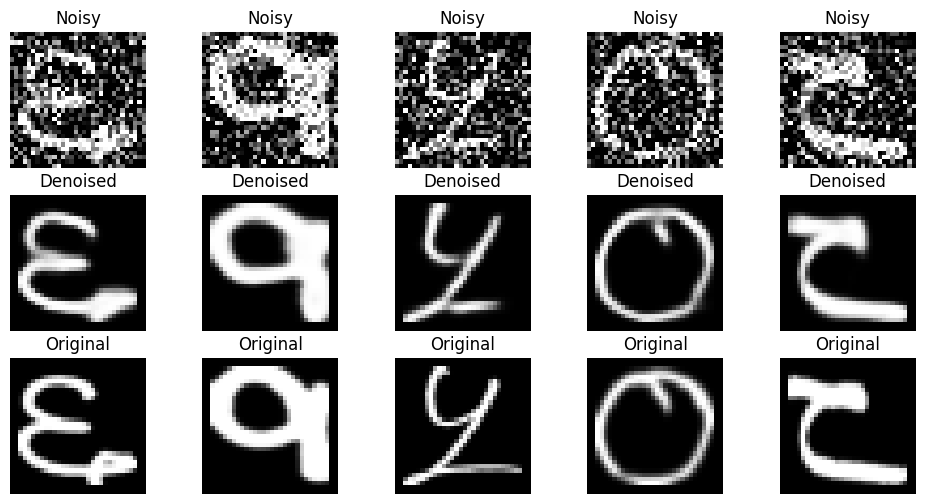

In [21]:
decoded_imgs = autoencoder.predict(x_val_noisy)

n = 5
plt.figure(figsize=(12, 6))

for i in range(n):
    # Noisy
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_val_noisy[i].reshape(32, 32), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(32, 32), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_val[i].reshape(32, 32), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()